## Introduction

This project aims to build a machine learning model to classify chest X-ray images into two categories:
- Normal
- Pneumonia
The goal is to explore whether a model can automatically detect pneumonia from medical images.

### Project overview

The dataset is composed of chest X-ray images divided into:

training set
validation set
test set

### Why Logistic Regression?

Logistic Regression was chosen for several reasons:

- It is a simple and beginner-friendly model
- It is well adapted for binary classification
- It allows easy understanding of:
    - model behavior
    - overfitting
    - impact of preprocessing
- It provides a solid baseline before testing more complex models

This choice allows focusing on understanding the full machine learning pipeline before moving to more advanced models.

In [1]:
from t_dev_810.data.loader import load
from t_dev_810.utils import display_distribution, show_image_from_path, show_image_size, display_experiment_from_json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from typing import List



data = load()

## Data Visualization

### Class Distribution

The dataset is imbalanced, with significantly more pneumonia cases than normal cases.

This imbalance can bias the model toward predicting pneumonia more often. However, in a medical context, prioritizing the detection of pneumonia (high recall) is important.

The dataset is split into training, validation, and test sets. The validation set is relatively small, which may impact the reliability of hyperparameter tuning.

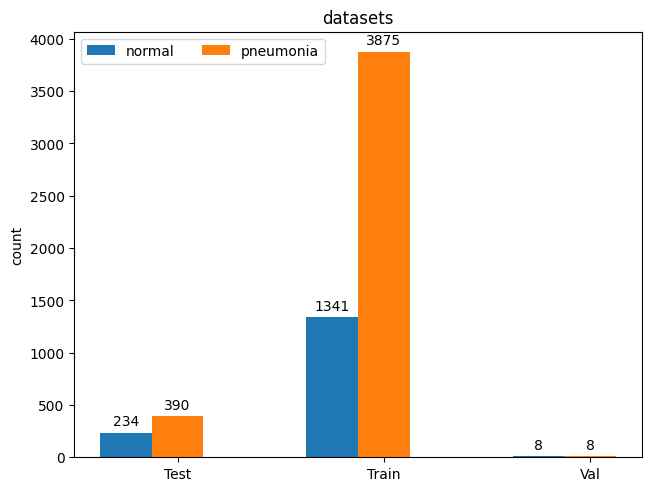

In [2]:
display_distribution(dataset=data)

### Sample Images

The images are grayscale chest X-rays.

We can observe visible differences between normal and pneumonia cases, particularly in lung opacity.

However, several challenges are present:
- Some images contain annotations or markers on the borders
- There is significant empty space and borders around the lungs
- Image quality and contrast vary across samples

These factors may introduce noise and affect model performance.

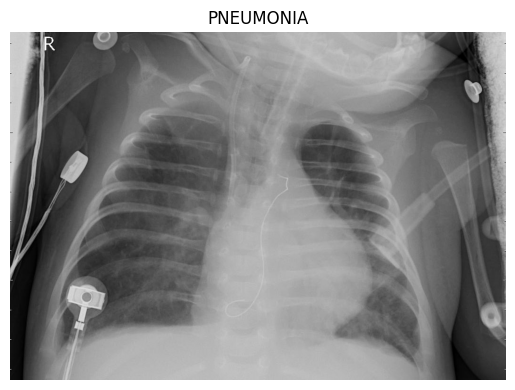

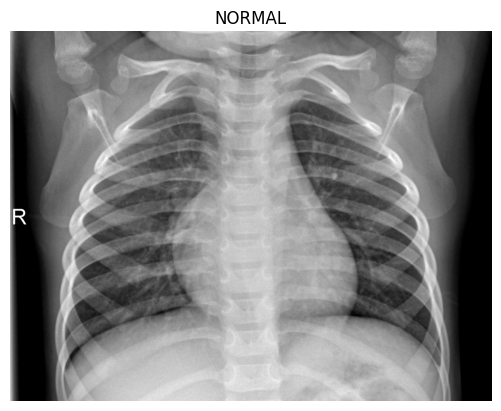

In [3]:
show_image_from_path(data.train[0].path, label=data.train[0].label)
show_image_from_path(data.train[-1].path, label=data.train[-1].label)

### Image Size Distribution

The dataset contains images with varying resolutions.

This inconsistency makes it necessary to resize all images to a fixed size before training.

Standardizing image dimensions ensures compatibility with machine learning models and improves training stability.

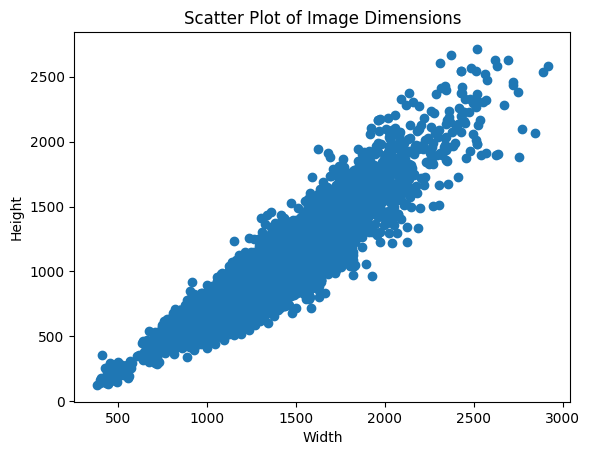

In [4]:
show_image_size(data)

### Conclusion

From this analysis, several important points emerge:

- The dataset is imbalanced, with more pneumonia cases than normal cases  
- The validation set is relatively small  
- Images have varying sizes and must be resized  
- Some images contain noise (annotations, borders)

To address these issues, the preprocessing pipeline will include:

- Image resizing to a fixed dimension  
- Cropping to remove unnecessary borders  
- Normalization of pixel values  

Additionally, the small size of the validation set may require adjusting the data split.

While the class imbalance may help prioritize pneumonia detection, it could also impact model generalization. If needed, techniques such as data augmentation or rebalancing may be explored.

# Preprocessing

## Overview

Before training the model, several preprocessing techniques were applied to improve data quality and model performance.

These steps aim to:
- standardize the input data
- reduce noise
- improve model generalization
- reduce overfitting

---

## Image Resizing

All images are resized to a fixed dimension.

**Why?**

The dataset contains images with different resolutions. Machine learning models require inputs of consistent size.

Resizing ensures:
- uniform input shape
- faster computation
- reduced complexity

However, reducing image size too much may lead to loss of important information.

---

## Image Cropping

Cropping is applied to remove borders around the images.

**Why?**

From dataset analysis, many images contain:
- unnecessary borders
- annotations or artifacts

Cropping helps:
- focus on relevant regions (lungs)
- reduce noise
- improve feature quality

---

## Color Enhancement

A color (contrast) enhancement factor can be applied.

**Why?**

Some images have low contrast, making patterns harder to detect.

Enhancement can:
- improve visibility of lung structures
- highlight differences between normal and pneumonia cases

However, excessive enhancement may distort the data.

---

## Normalization

Pixel values are normalized.

**Why?**

Raw pixel values range from 0 to 255. This scale can negatively impact model training.

Normalization:
- scales values to a smaller range (e.g. 0–1)
- stabilizes training
- improves convergence

---

## Dimensionality Reduction (PCA)

Principal Component Analysis (PCA) can be applied to reduce the number of features.

**Why?**

Images converted to vectors contain a large number of features.

PCA helps:
- reduce dimensionality
- remove noise
- reduce overfitting

However, too much reduction may remove useful information.

---

## Class Weight

Class weights can be adjusted to handle dataset imbalance.

**Why?**

The dataset contains more pneumonia cases than normal cases.

Using class weights allows:
- penalizing misclassification of minority class
- improving recall for underrepresented class

This is important in medical contexts where missing a disease is critical.

---

## Regularization

Regularization is controlled using parameter **C** and penalty type (L1, L2, ElasticNet).

**Why?**

Regularization helps prevent overfitting by constraining the model.

- **L2**: stabilizes weights  
- **L1**: performs feature selection  
- **ElasticNet**: combines both approaches  

The parameter **C** controls the strength of regularization.

---

## Solver Selection

Different solvers are used depending on the configuration.

**Why?**

Each solver has different properties:
- `lbfgs`: stable and efficient for L2  
- `liblinear`: good for small datasets  
- `saga`: supports L1 and ElasticNet  

Choosing the correct solver ensures compatibility and performance.

---

## Conclusion

These preprocessing steps are essential to improve model performance.

They allow:
- cleaning and standardizing the data  
- reducing noise and irrelevant information  
- controlling model complexity  

The impact of each step will be evaluated through experiments to determine the most effective configuration.

# Evaluation Metrics

To evaluate the model performance, several metrics were selected, with a particular focus on pneumonia detection.

---

## Choice of Metrics

Since the objective of this project is to detect pneumonia cases, **recall** is a key metric.

A high recall ensures that most pneumonia cases are correctly identified, which is critical in a medical context where missing a disease (false negative) can have serious consequences.

However, recall alone is not sufficient.

- A model predicting only "pneumonia" would achieve high recall but poor performance overall  
- Therefore, recall is combined with **precision** and **F1-score**

These metrics allow us to:
- evaluate the balance between false positives and false negatives  
- ensure the model is not biased toward predicting only one class  

---

## Selected Metrics

The following metrics are used:

- **Accuracy**: overall performance of the model  
- **Recall**: ability to detect pneumonia cases  
- **Precision**: reliability of positive predictions  
- **F1-score**: balance between precision and recall  
- **AUC (ROC)**: ability to separate classes  
- **Confusion Matrix**: detailed analysis of prediction errors  

---

## Overfitting Consideration

During experimentation, overfitting was identified as a major issue.

To monitor this, the following comparison is used:

- **Train AUC (cross-validation AUC)**
- **Test AUC**

A large difference between these values indicates that the model performs well on training data but fails to generalize.

---

## Confusion Matrix Analysis

The confusion matrix provides a detailed view of prediction errors:

- **True Positives (TP)**: correctly detected pneumonia cases  
- **False Positives (FP)**: normal cases predicted as pneumonia  
- **True Negatives (TN)**: correctly detected normal cases  
- **False Negatives (FN)**: missed pneumonia cases  

In this context, minimizing **false negatives** is particularly important, as they represent undetected pneumonia cases.

---

## Conclusion

The evaluation strategy focuses on balancing:

- high recall (to detect pneumonia cases)  
- acceptable precision (to avoid too many false alarms)  
- good generalization (by comparing train and test AUC)  

This combination of metrics provides a more complete and reliable evaluation of the model performance.

# Experiments

In this section, multiple experiments are conducted to evaluate the impact of different preprocessing techniques and model configurations.

Each experiment includes:
- a hypothesis
- selected parameters
- results
- analysis

### First hypothesis


## Experiment — 2026-03-30T20:50:15.973318

### Hypothesis
first try to have result reference with default config

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: None
- **Crop factor**: 0
- **Enhance factor**: 0
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 1.000
- **Class weight**: False
- **Max iter**: 2000

### Results


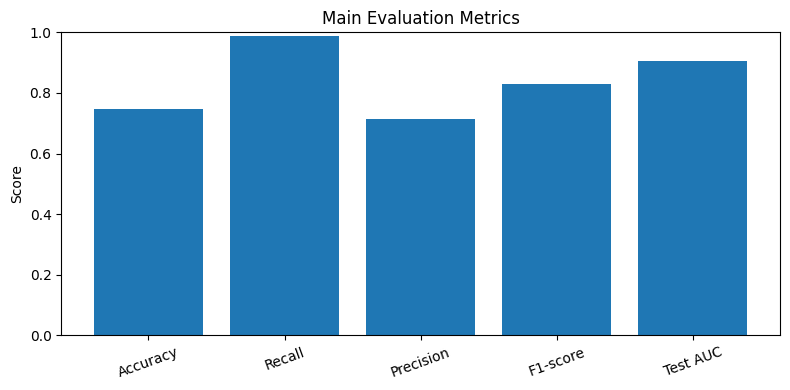

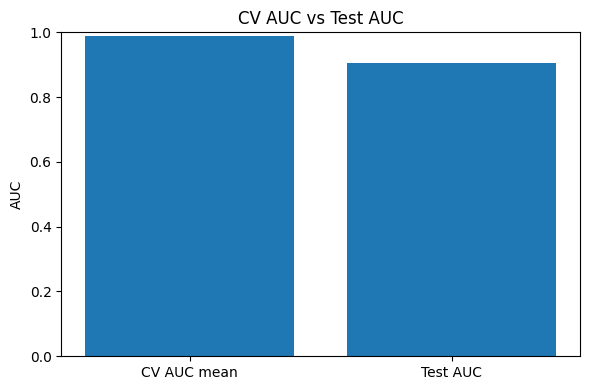

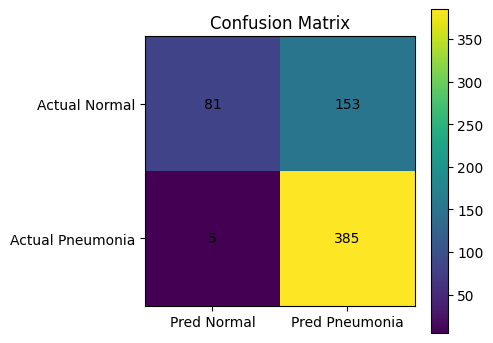

In [5]:
display_experiment_from_json('2026-03-30T20:50:15.973318')

### Analysis

This first experiment serves as a **baseline** with default parameters and no advanced preprocessing.

**Key observations:**

- **Recall is excellent (98.7%)**: the model detects almost all pneumonia cases, with only 5 false negatives. This is critical in a medical context.
- **Precision is low (71.6%)**: 153 normal cases are incorrectly classified as pneumonia. The model is biased toward predicting the majority class (pneumonia), likely due to the dataset imbalance and the absence of class weight balancing.
- **Accuracy (74.7%)** is moderate, dragged down by the high number of false positives.
- **Overfitting is present**: the gap between CV AUC (0.988) and Test AUC (0.905) indicates that the model memorizes training data better than it generalizes. This is expected with 4096 raw features (64x64) and no dimensionality reduction.

**Conclusion:**

The baseline confirms that logistic regression can detect pneumonia effectively, but struggles with specificity. The next experiments should focus on:
- reducing overfitting (PCA, stronger regularization)
- improving precision (class weight balancing, crop/enhance preprocessing)

### Second hypothesis


## Experiment — 2026-04-27T09:45:46.269484

### Hypothesis
Tried to reduce overfitting with reducing features with image size at 64 and use PCA components at 150

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: 150
- **Crop factor**: 0
- **Enhance factor**: 0
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 1.000
- **Class weight**: False
- **Max iter**: 2000

### Results


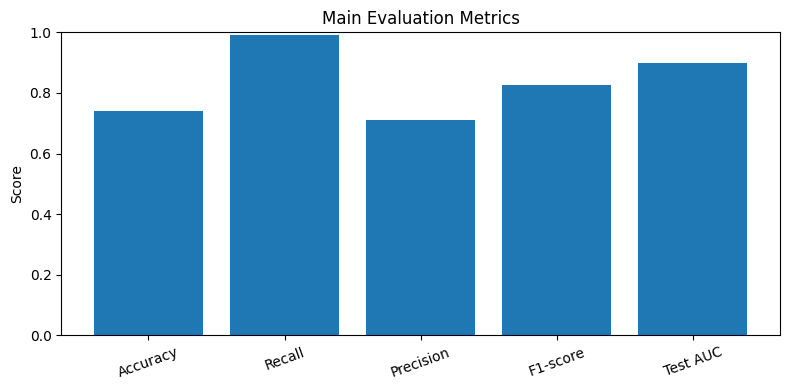

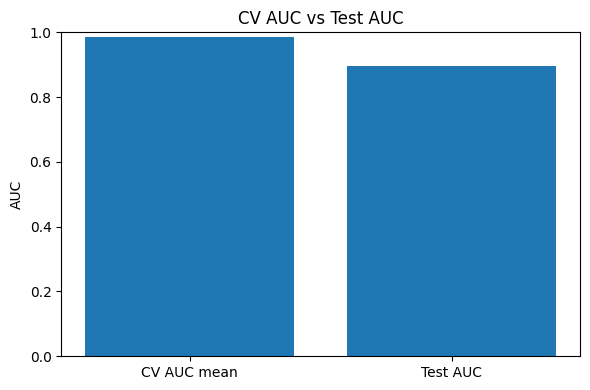

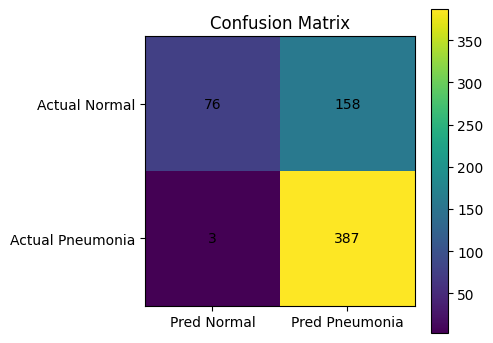

In [6]:
display_experiment_from_json('2026-04-27T09:45:46.269484')

### Analysis

This experiment tested whether PCA (150 components) could reduce overfitting by lowering the feature space from 4096 to 150.

**Key observations:**

- **Overfitting was not reduced**: the gap between CV AUC (0.986) and Test AUC (0.897) is 0.089, slightly worse than the baseline gap of 0.083. PCA alone is not sufficient to address overfitting here.
- **Recall improved slightly (99.2% vs 98.7%)**: only 3 false negatives instead of 5. However, this came at the cost of more false positives (158 vs 153).
- **Precision dropped (71.0% vs 71.6%)**: the model became even more biased toward predicting pneumonia.
- **Overall performance is nearly identical to baseline**: accuracy, F1, and AUC values are within noise margin.

**Conclusion:**

PCA with 150 components does not meaningfully improve the model. The dimensionality reduction alone is not enough — the model still overfits. The next experiment should focus on **stronger regularization (lower C)** to directly constrain the model weights, which is a more effective lever against overfitting than feature reduction alone.

### Third hypothesis


## Experiment — 2026-04-27T09:58:37.325398

### Hypothesis
Reducing the value of C will increase regularization strength, which should reduce overfitting by limiting model complexity.

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: None
- **Crop factor**: 0
- **Enhance factor**: 0
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 0.100
- **Class weight**: False
- **Max iter**: 2000

### Results


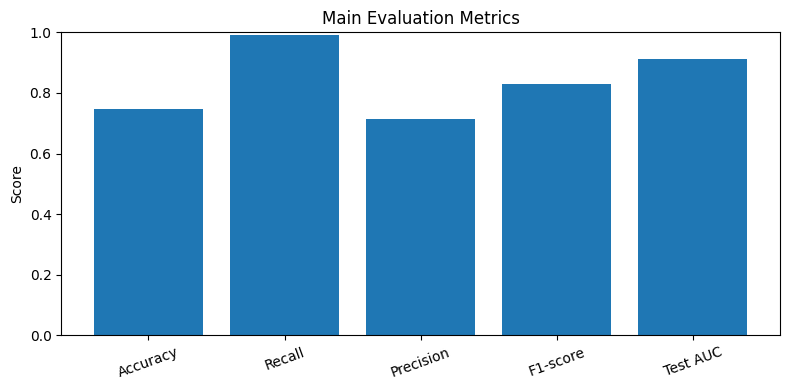

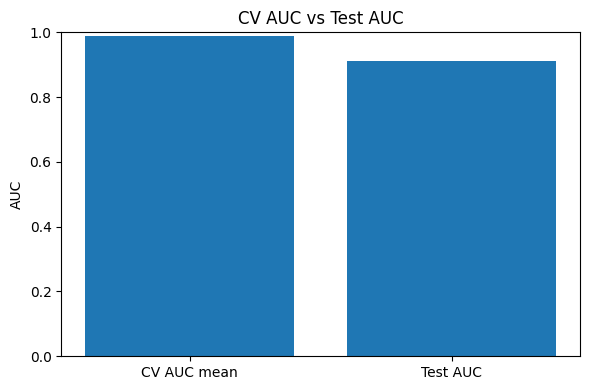

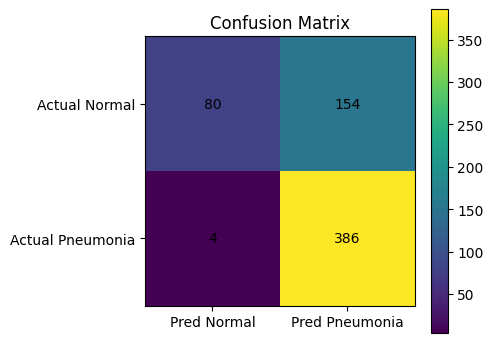

In [7]:
display_experiment_from_json("2026-04-27T09:58:37.325398")

### Analysis

This experiment tested whether stronger regularization (C=0.1 instead of C=1.0) could reduce overfitting.

**Key observations:**

- **Results are nearly identical to the baseline**: accuracy stays at 74.7%, F1 at 0.830, and the confusion matrix barely changes (TP=386, FP=154, TN=80, FN=4).
- **Test AUC improved slightly (0.911 vs 0.905)**: the overfitting gap narrowed from 0.083 to 0.077, which is a small but positive signal.
- **Recall increased marginally (99.0% vs 98.7%)** with only 4 false negatives instead of 5, but precision dropped slightly (71.5% vs 71.6%).
- Overall, lowering C from 1.0 to 0.1 has a minimal effect. The regularization change is not strong enough to significantly alter the model's decision boundary.

**Conclusion:**

Moderate regularization alone does not meaningfully improve performance. The overfitting gap is slightly reduced but the precision problem remains. The next experiment should address the **class imbalance** directly using `class_weight=balanced`.

### Fourth hypothesis


## Experiment — 2026-04-27T10:10:17.231782

### Hypothesis
In this experiment, class_weight is set to "balanced" to address class imbalance.This is expected to reduce the number of false positives by penalizing mistakes on the minority class more strongly, leading to a better balance between precision and recall.

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: None
- **Crop factor**: 0
- **Enhance factor**: 0
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 1.000
- **Class weight**: True
- **Max iter**: 2000

### Results


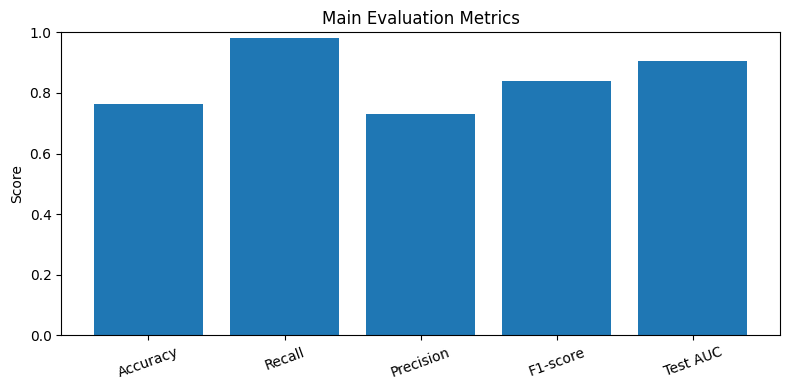

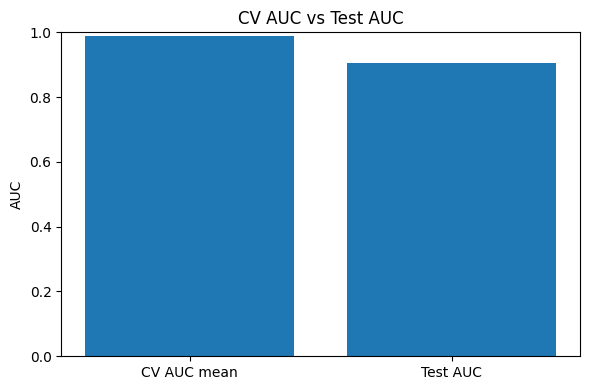

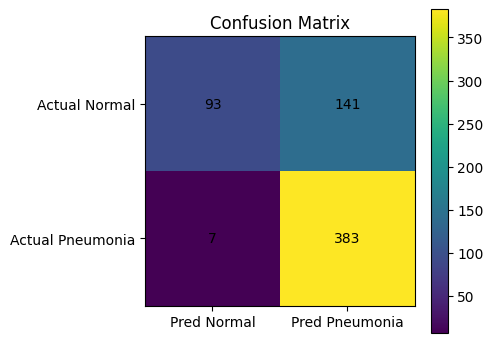

In [8]:
display_experiment_from_json("2026-04-27T10:10:17.231782")

### Analysis

This experiment enabled `class_weight=balanced` to address the dataset imbalance by penalizing misclassifications on the minority class (NORMAL) more heavily.

**Key observations:**

- **Best results so far across most metrics**:
  - Accuracy improved from 74.7% to **76.3%** (+1.6%)
  - Precision improved from 71.6% to **73.1%** (+1.5%)
  - F1-score improved from 0.830 to **0.838** (+0.008)
- **False positives dropped significantly**: 141 vs 153 in baseline (-12 FP), meaning 12 more normal cases are correctly classified (TN: 93 vs 81).
- **Small recall trade-off**: recall dropped slightly from 98.7% to 98.2% (7 FN vs 5). This is an acceptable trade-off — the model misses 2 more pneumonia cases but correctly identifies 12 more normal cases.
- **Overfitting gap remains similar**: CV AUC (0.988) vs Test AUC (0.904), gap of 0.084.

**Conclusion:**

Class weight balancing is the **first lever that meaningfully improved** the model. It successfully shifted the decision boundary to reduce the bias toward predicting pneumonia, improving precision and accuracy without a major loss in recall. The next experiments should build on this configuration and explore combining `class_weight=balanced` with other techniques (PCA, crop, or lower C) to further improve results.

### Fifth hypothesis


## Experiment — 2026-04-27T10:17:30.604099

### Hypothesis
In this experiment, PCA is combined with class_weight="balanced" to evaluate whether reducing the number of features improves model performance once class imbalance has been addressed.

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: 150
- **Crop factor**: 0
- **Enhance factor**: 0
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 1.000
- **Class weight**: True
- **Max iter**: 2000

### Results


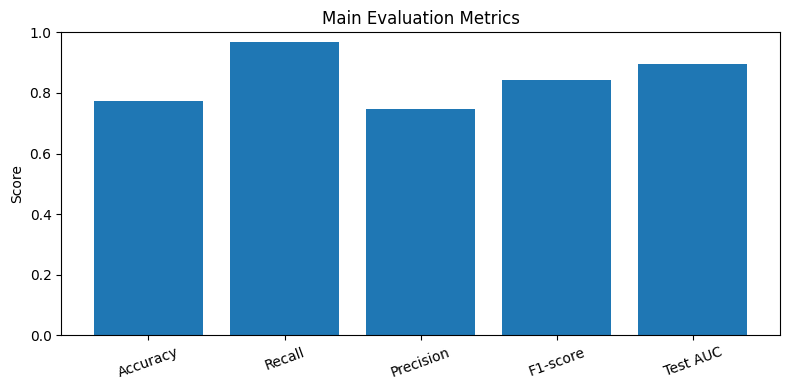

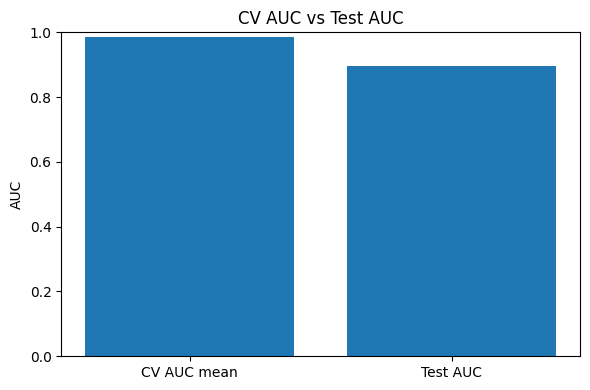

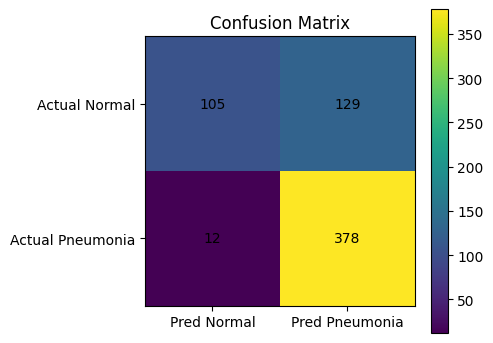

In [9]:
display_experiment_from_json("2026-04-27T10:17:30.604099")

### Analysis

This experiment combined PCA (150 components) with `class_weight=balanced` to evaluate whether dimensionality reduction improves results once class imbalance is addressed.

**Key observations:**

- **Best accuracy (77.4%) and F1-score (0.843) so far**: this combination outperforms all previous experiments on overall metrics.
- **Precision continues to improve**: 74.6% vs 73.1% (exp 4) vs 71.6% (baseline). False positives dropped to 129, down from 153 in baseline — 24 fewer normal cases misclassified.
- **Recall trade-off is more significant**: 96.9% vs 98.2% (exp 4), with 12 false negatives vs 7. In a medical context, missing 12 pneumonia cases instead of 7 is a meaningful cost.
- **Overfitting gap slightly increased**: CV AUC (0.986) vs Test AUC (0.896), gap of 0.090. PCA did not help reduce overfitting here either.

**Conclusion:**

The combination of class weight balancing and PCA yields the best overall balance between precision and recall. However, the recall drop (from 98.7% to 96.9%) raises a question: **is the precision gain worth the additional missed pneumonia cases?** In a screening context, a higher recall may be preferred. The next experiments should explore whether image preprocessing (crop, enhance) can improve precision while maintaining higher recall.

### Sixth hypothesis


## Experiment — 2026-04-27T10:25:53.082068

### Hypothesis
Improve the quality of the input signal rather than reducing the number of features, in order to increase precision without sacrificing recall.

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: None
- **Crop factor**: 10
- **Enhance factor**: 0
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 1.000
- **Class weight**: True
- **Max iter**: 2000

### Results


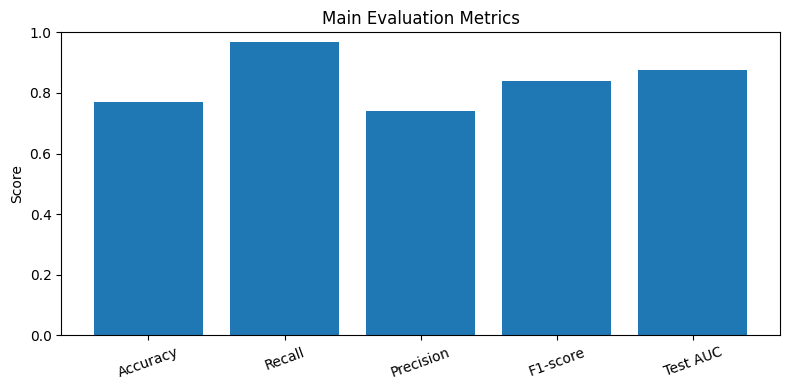

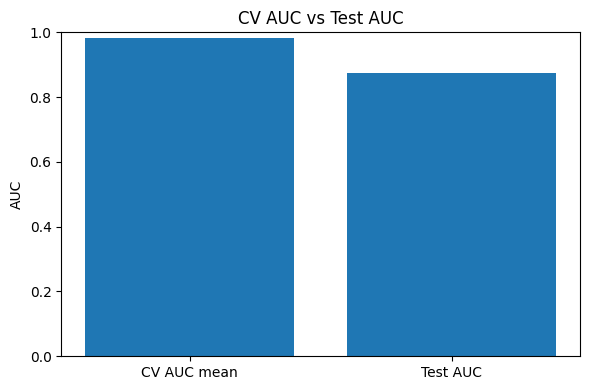

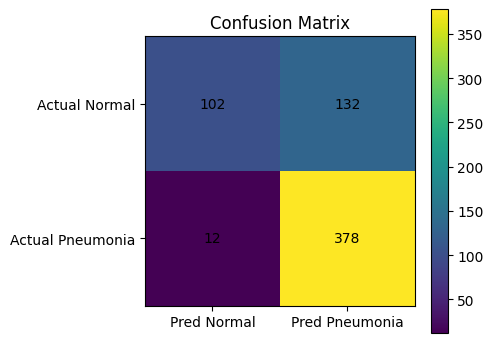

In [10]:
display_experiment_from_json("2026-04-27T10:25:53.082068")

### Analysis

This experiment added cropping (factor=10) to the class_weight=balanced configuration, aiming to improve input quality by removing image borders.

**Key observations:**

- **Accuracy (76.9%) and F1 (0.840) are between exp 4 and exp 5**: crop provides a slight improvement over class_weight alone but does not outperform the PCA+balanced combination.
- **Precision (74.1%) improved over exp 4 (73.1%)**: FP dropped to 132 vs 141. Removing borders helped the model better distinguish normal cases.
- **Recall did not improve as hoped**: 96.9% with 12 FN, same as exp 5. The crop did not help maintain high recall — it may be removing some useful edge information.
- **Overfitting gap worsened significantly**: CV AUC (0.982) vs Test AUC (0.875), gap of 0.107. This is the worst generalization gap so far, suggesting that cropping at 64x64 resolution removes too much information and the model overfits to the remaining features.

**Conclusion:**

Cropping provides marginal precision gains but hurts generalization. At 64x64, the images are already small — removing 10 pixels from each side loses a significant portion of the image. The best configuration so far remains **exp 5 (PCA + class_weight=balanced)** for overall metrics, or **exp 4 (class_weight=balanced only)** if maximizing recall is the priority.

### Seventh Hypothesis


## Experiment — 2026-04-27T13:44:55.437271

### Hypothesis
GridSearch to find optimal hyperparameters (solver, penalty, C, class_weight) with default preprocessing

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: None
- **Crop factor**: 0
- **Enhance factor**: 0
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 1
- **Class weight**: None
- **Max iter**: 2000

### Results


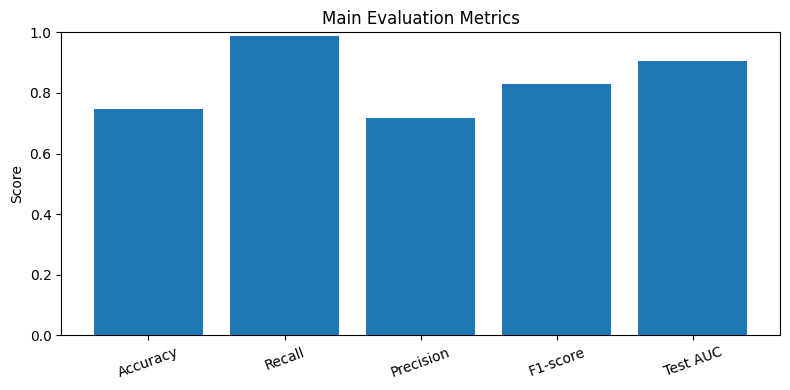

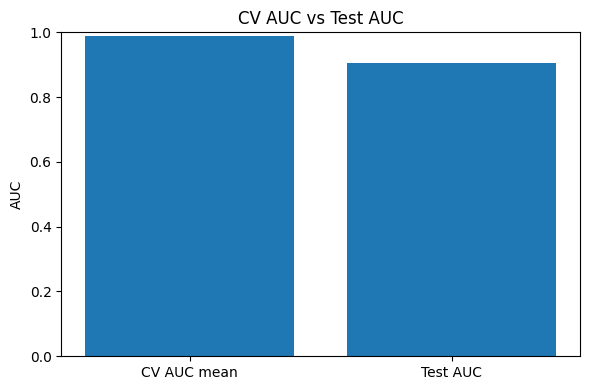

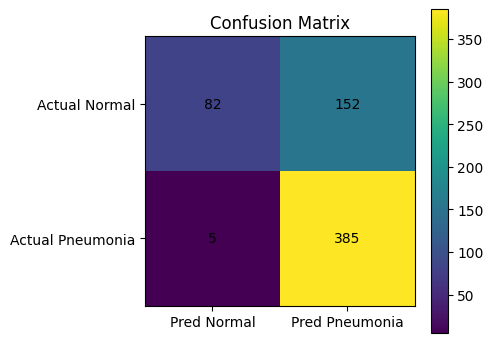

In [11]:
display_experiment_from_json("2026-04-27T13:44:55.437271")

### Analysis

This experiment used GridSearchCV to automatically explore 48 combinations of hyperparameters (solver, penalty, C, l1_ratio, class_weight) across lbfgs, liblinear, and saga solvers.

**Key observations:**

- **GridSearch selected the default configuration**: `liblinear + l2 + C=1.0 + class_weight=None` — essentially the same as the baseline (exp 1). After 3 hours of computation, the best parameters found are the scikit-learn defaults.
- **Results are nearly identical to the baseline**: accuracy 74.8%, recall 98.7%, precision 71.7%, F1 0.831, Test AUC 0.904.
- **Why did GridSearch not select `class_weight=balanced`?** The issue is that `GridSearchCV` was configured without a `scoring` parameter, so it defaults to optimizing **accuracy**. With an imbalanced dataset, accuracy favors predicting the majority class (pneumonia) — which is exactly what the model does without class weighting. The grid search correctly found that, for pure accuracy, ignoring class weights is slightly better.
- This is a **scoring metric problem, not a model problem**. Exp 4 showed that `class_weight=balanced` improves F1 and precision, but GridSearch was not told to optimize for those metrics.

**Conclusion:**

This experiment highlights the importance of choosing the right optimization metric. GridSearchCV should use `scoring='f1'` or `scoring='roc_auc'` instead of the default accuracy, especially with imbalanced datasets. The raw computation was not wasted — it confirms that the default hyperparameters are already optimal for accuracy, and that further improvements must come from addressing class imbalance (as shown in exp 4 and 5).

### Eighth hypothesis


## Experiment — 2026-04-27T17:11:56.530702

### Hypothesis
GridSearch with scoring='f1' to find optimal hyperparameters optimizing for F1-score instead of accuracy

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: None
- **Crop factor**: 0
- **Enhance factor**: 0
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 1
- **Class weight**: None
- **Max iter**: 2000

### Results


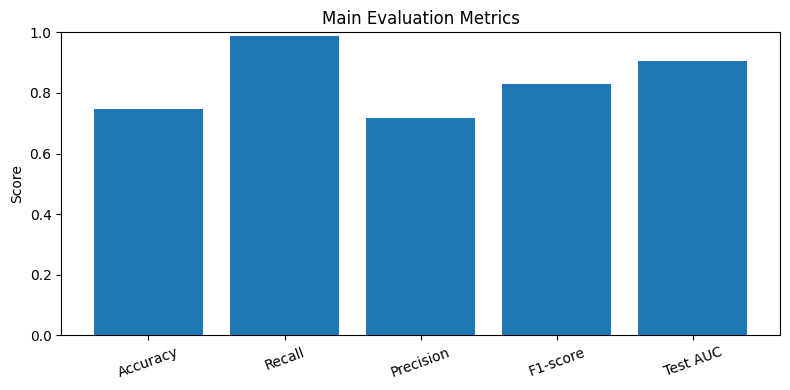

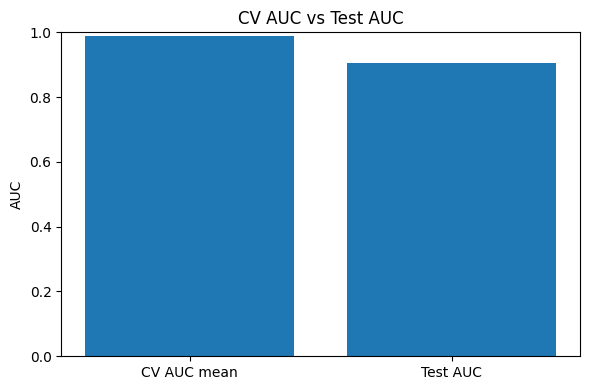

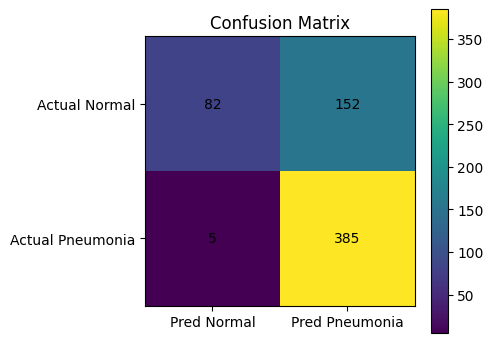

In [12]:
display_experiment_from_json("2026-04-27T17:11:56.530702")

### Analysis

This experiment re-ran the GridSearch with `scoring='f1'` instead of the default accuracy, to verify whether optimizing for F1-score would select `class_weight=balanced`.

**Key observations:**

- **Same best parameters as exp 7**: `liblinear + l2 + C=1.0 + class_weight=None`. Changing the scoring metric from accuracy to F1 did not change the outcome.
- **Results are identical**: accuracy 74.8%, recall 98.7%, precision 71.7%, F1 0.831.
- **Why?** During cross-validation, the F1 scores for `class_weight=None` and `class_weight=balanced` are close enough that the grid search does not consistently prefer balanced. The improvement we observed in exp 4 on the test set may not generalize across all CV folds.
- This highlights an important distinction: **a single held-out test set can show improvements that don't hold up under cross-validation**. The exp 4 improvement (F1: 0.838 vs 0.830) was real on our test set but not robust enough to be captured by 5-fold CV.

**Conclusion:**

The GridSearch confirms that `liblinear + l2 + C=1.0` is a stable optimum regardless of the scoring metric. The `class_weight=balanced` improvement from exp 4 is test-set specific rather than a generalizable gain. This suggests that the model has reached a performance plateau with this feature set and preprocessing — further improvements would likely require different feature engineering or a more expressive model.

### Ninth hypothesis


## Experiment — 2026-04-27T17:26:02.259771

### Hypothesis
Test contrast enhancement (factor=2) with class_weight=balanced to improve input signal quality

### Parameters
- **Image size**: 64x64
- **Normalize**: True
- **PCA components**: None
- **Crop factor**: 0
- **Enhance factor**: 2
- **Model**: logistic_regression
- **Penalty**: l2
- **Solver**: liblinear
- **L1 ratio**: None
- **Regularization C**: 1.000
- **Class weight**: True
- **Max iter**: 2000

### Results


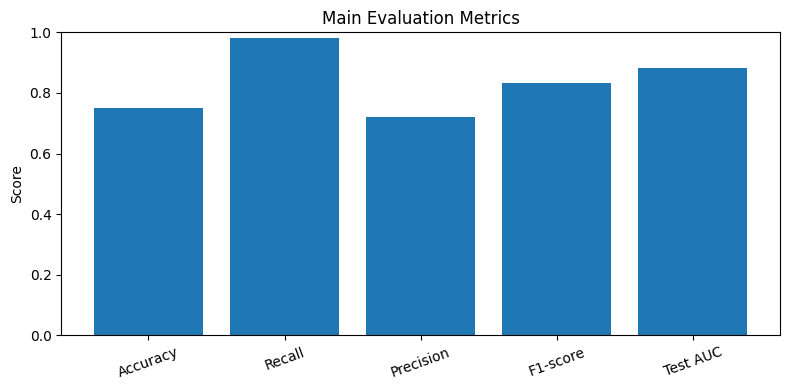

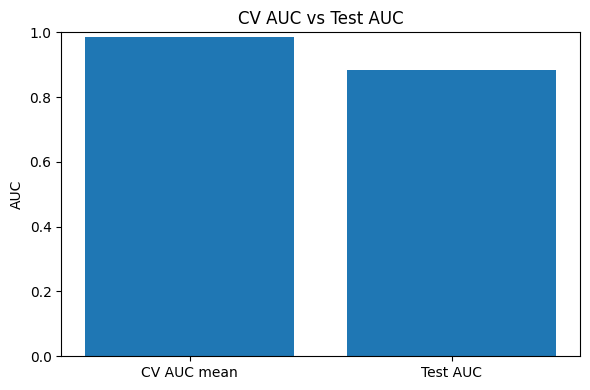

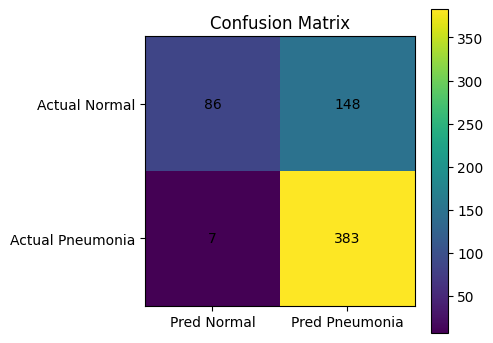

In [13]:
display_experiment_from_json("2026-04-27T17:26:02.259771")

### Analysis

This experiment tested contrast enhancement (factor=2) combined with `class_weight=balanced`, aiming to improve input signal quality.

**Key observations:**

- **Performance is worse than exp 4 (balanced alone)**: accuracy 75.2% vs 76.3%, precision 72.1% vs 73.1%, F1 0.832 vs 0.838. Contrast enhancement degraded results instead of improving them.
- **Recall is unchanged at 98.2%** (7 FN), same as exp 4 — the enhancement did not affect the model's ability to detect pneumonia.
- **More false positives**: 148 vs 141 (exp 4). The enhanced contrast appears to introduce noise that makes normal cases harder to classify correctly.
- **Overfitting gap worsened**: CV AUC (0.987) vs Test AUC (0.884), gap of 0.103. Similar to cropping (exp 6), modifying the raw image data at low resolution hurts generalization.

**Conclusion:**

Contrast enhancement does not improve the model and actually degrades performance compared to `class_weight=balanced` alone. At 64x64 resolution, the pixel-level transformations (crop, enhance) consistently hurt generalization. The model performs best with minimal preprocessing and class weight adjustment. This confirms that **exp 4 (class_weight=balanced)** and **exp 5 (PCA + balanced)** remain the best configurations found.

# Conclusion

## Summary of experiments

| Exp | Configuration | Accuracy | Recall | Precision | F1 | Test AUC | AUC Gap |
|-----|--------------|----------|--------|-----------|------|----------|---------|
| 1 | Baseline (default) | 74.7% | 98.7% | 71.6% | 0.830 | 0.905 | 0.083 |
| 2 | PCA 150 | 74.2% | 99.2% | 71.0% | 0.828 | 0.897 | 0.089 |
| 3 | C=0.1 | 74.7% | 99.0% | 71.5% | 0.830 | 0.911 | 0.077 |
| 4 | **class_weight=balanced** | **76.3%** | **98.2%** | 73.1% | 0.838 | 0.904 | 0.084 |
| 5 | PCA + balanced | **77.4%** | 96.9% | **74.6%** | **0.843** | 0.896 | 0.090 |
| 6 | Crop + balanced | 76.9% | 96.9% | 74.1% | 0.840 | 0.875 | 0.107 |
| 7 | GridSearch (accuracy) | 74.8% | 98.7% | 71.7% | 0.831 | 0.904 | 0.084 |
| 8 | GridSearch (F1) | 74.8% | 98.7% | 71.7% | 0.831 | 0.904 | 0.084 |
| 9 | Enhance + balanced | 75.2% | 98.2% | 72.1% | 0.832 | 0.884 | 0.103 |

## Key findings

1. **Class imbalance was the main issue**: `class_weight=balanced` was the only lever that produced a meaningful improvement. PCA, regularization, crop, and contrast enhancement had marginal or negative effects.

2. **Image preprocessing hurts at low resolution**: cropping and contrast enhancement consistently worsened generalization (higher AUC gap). At 64x64, the images are too small to benefit from pixel-level transformations.

3. **GridSearch confirmed model stability**: regardless of the scoring metric (accuracy or F1), the optimal hyperparameters remained `liblinear + l2 + C=1.0`. The model has reached a performance plateau for logistic regression on this feature set.

4. **Overfitting persists across all experiments**: the gap between CV AUC (~0.988) and Test AUC (~0.90) is present in every configuration. This is a fundamental limitation of logistic regression on flattened image features.

## Best model selection

**Selected model: Experiment 4 — `class_weight=balanced`**

| Metric | Value |
|--------|-------|
| Accuracy | 76.3% |
| Recall | 98.2% |
| Precision | 73.1% |
| F1-score | 0.838 |
| Test AUC | 0.904 |
| False Negatives | 7 |

**Why this model over exp 5 (PCA + balanced)?**

Exp 5 has better accuracy (77.4%) and F1 (0.843), but exp 4 was chosen because:

- **Higher recall (98.2% vs 96.9%)**: in a medical screening context, missing a pneumonia case (false negative) is more dangerous than a false alarm (false positive). Exp 4 misses 7 cases vs 12 for exp 5 — that is 5 additional undetected pneumonia cases.
- **Better generalization**: exp 4 has a smaller AUC gap (0.084 vs 0.090), meaning its performance is more likely to hold on unseen data.
- **Simpler pipeline**: no PCA step required, making the model easier to deploy and maintain.

In a clinical setting, a model that rarely misses pneumonia — even at the cost of some false alarms — is preferred. False positives lead to additional tests, while false negatives lead to missed diagnoses.